# Eksperimen Model: Multi-Layer Perceptron (Deep Learning Dasar)
Jaringan Saraf Tiruan (ANN) yang memproses fitur MFCC 1D. Menggunakan TensorFlow/Keras untuk melacak pergerakan Akurasi dan Loss (Learning Curve).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

print(f'TensorFlow Version: {tf.__version__}')

TensorFlow Version: 2.21.0


### 1. Data Prep (StandardScaler sangat disarankan untuk Neural Network)

In [2]:
X = np.load('X_features.npy')
y = np.load('y_labels.npy')
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

import joblib
joblib.dump(scaler, 'models/scaler_mlp.pkl')

['models/scaler_mlp.pkl']

### 2. Membangun Arsitektur Keras

In [3]:
model = Sequential([
    Dense(256, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dense(8, activation='softmax') # 7 Kelas bahasa
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()

c:\Users\fadli ahmad fahrezi\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │        10,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 8)              │           520 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 52,168 (203.78 KB)

 Trainable params: 52,168 (203.78 KB)

 Non-trainable params: 0 (0.00 B)

### 3. Pelatihan Model dengan Early Stopping

In [4]:
# Early stopping untuk mencegah Overfitting
es = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

history = model.fit(
    X_train_scaled, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    callbacks=[es],
    verbose=1
)

Epoch 1/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.2490 - loss: 1.8902 - val_accuracy: 0.3750 - val_loss: 1.6460
Epoch 2/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.4315 - loss: 1.5044 - val_accuracy: 0.5139 - val_loss: 1.3078
Epoch 3/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.5208 - loss: 1.2769 - val_accuracy: 0.5714 - val_loss: 1.1605
Epoch 4/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5680 - loss: 1.1626 - val_accuracy: 0.6091 - val_loss: 1.0914
Epoch 5/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6275 - loss: 1.0165 - val_accuracy: 0.6091 - val_loss: 1.0324
Epoch 6/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.6438 - loss: 0.9404 - val_accuracy: 0.6528 - val_loss: 0.9795
Epoch 7/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6865 - loss: 0.8834 - val_accuracy: 0.6687 - val_loss: 0.9396
Epoch 8/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7063 - loss: 0.7898 - val_accuracy: 0.6746 -

### 4. Analisis Learning Curve

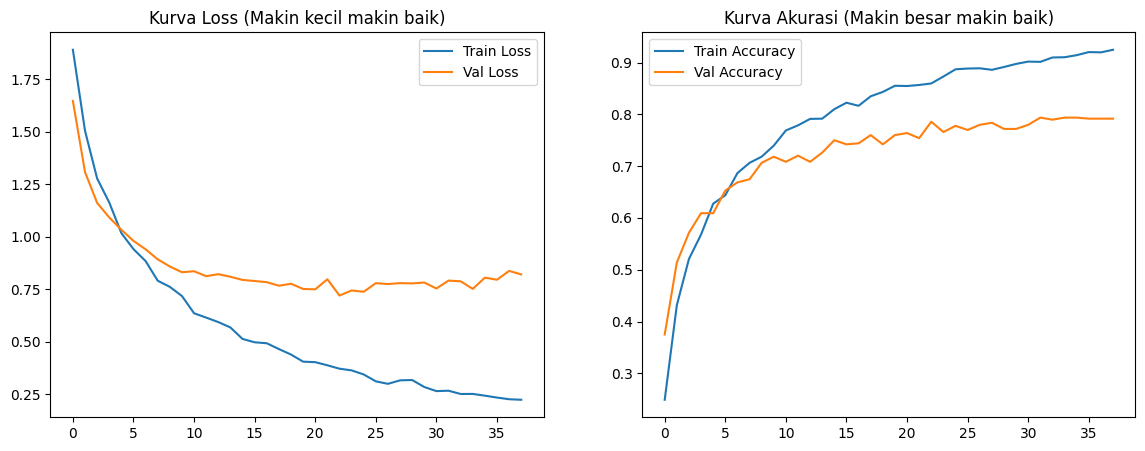

In [5]:
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Kurva Loss (Makin kecil makin baik)')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Kurva Akurasi (Makin besar makin baik)')
plt.legend()
plt.show()

### 5. Evaluasi & Confusion Matrix

20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
              precision    recall  f1-score   support

       horas       0.81      0.79      0.80        90
  sampurasun       0.68      0.66      0.67        90
adilkatalino       0.67      0.72      0.70        90
      wawawa       0.83      0.81      0.82        90
   kulanuwun       0.74      0.92      0.82        90
       tabea       0.85      0.76      0.80        90
     peuhaba       0.83      0.72      0.77        90

    accuracy                           0.77       630
   macro avg       0.77      0.77      0.77       630
weighted avg       0.77      0.77      0.77       630



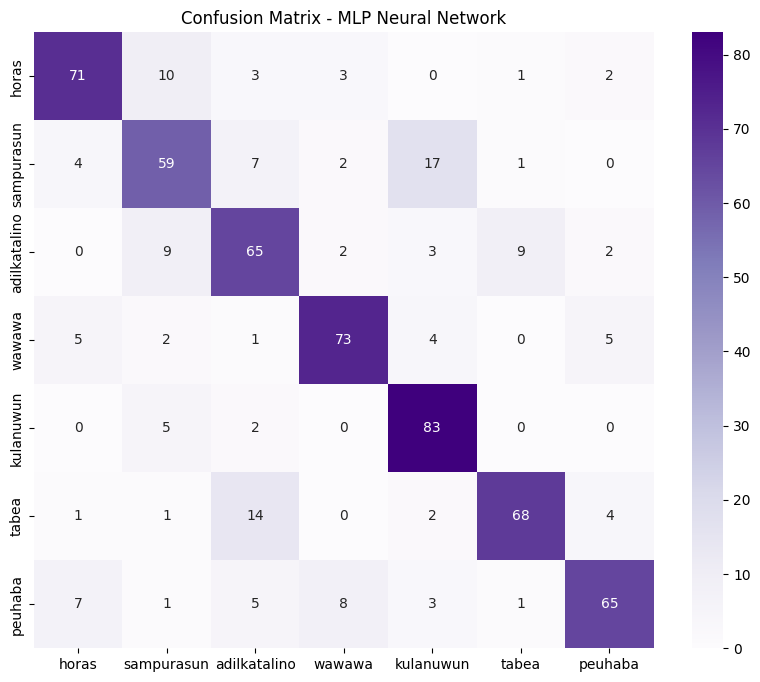

In [6]:
y_pred_probs = model.predict(X_test_scaled)
y_pred = np.argmax(y_pred_probs, axis=1)

classes = ['horas', 'sampurasun', 'adilkatalino', 'wawawa', 'kulanuwun', 'tabea', 'peuhaba']
print(classification_report(y_test, y_pred, target_names=classes))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', xticklabels=classes, yticklabels=classes)
plt.title('Confusion Matrix - MLP Neural Network')
plt.show()

### 6. Simpan Model Keras (.h5)

In [ ]:
model.save('models/mlp_model.h5')
print('Model MLP berhasil disimpan!')